# DISRA Science Case Module
##### **NAME:** Low-fidely Exo-Earth Yield Calculator
##### **PURPOSE:** Estimate the yield of exo-Earths using scaling laws from Stark+ 2014 and Stark+ 2015.
##### **BACKGROUND:**


```stark2014``` Reads a .sav file that contains the lookup table from Stark+ 2014. It parametrizes the limiting magnitude, exozodi, contrast limit, IWA, and diameter of the telescopes.

```stark2015``` Applies scaling laws outlined in Stark+ 2015.

In both cases, initial values are set to the defaults (zero points) given in each paper.


##### **INPUTS:**
```lim_mag```: expresses the faintest planet that can be detected at the desired S/N in a certain exposure time (Δmag$_{obs}$ in Stark+2014)\
```nexozod```: number of exozodis for the given system you are looking at (default = 3 exozodis)\
```contrast```: contrast floor for coronagrah (default = 1e-10)\
```iwa```: Inner working angle (IWA) of coronagraph instrument in λ/D (default = 3.6 λ/D)\
```diameter```: Diameter of the primary mirror in meters (default = 6 meters)\
```eta_earth```: fraction of anticipated Earth-like planets. (default = 0.1)\
```albedo```: Geometric albedo of the system you are looking at (default = 0.2)\
```throughput```: Optical throughput of the system in fractional units (default = 0.2)\
```bandwidth```: bandwidth of coronagraph system in fractional units (default = 0.1 [equivalent to 10%])\
```PSF_elongation```: PSF broadening of the planet signal in fracitonal units (default = 1.0)\
```OWA```: Outer working angle of the coronagraph in λ/D (default = 15 λ/D)\
```T_total```: Exposure time of the mission in years (default = 1 year)\
```SNR```: Required signal-to-noise ratio for a "detection" (default = 7)
##### **OUTPUTS:** Exo-Earth yield (double)
##### **MODIFICATION HISTORY:**
##### 9-Oct-2024: Initial port to Google Collab

In [1]:
import numpy as np
import scipy.interpolate
import scipy.io
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def stark2014(lim_mag, nexozod, contrast, iwa, diameter):
    dat = scipy.io.readsav('stark-yields/DISRA_exoplanet_yield_grid_Stark_2014.sav') #read in data table from Stark+2014
    npl = dat['np']
    npl = npl[:,0,:,:,:,:] #ignore eta_earth column; use scaling law from Stark+2015
    pos = (dat['limiting_magnitude_factor_list'], dat['nexozodis_list'], np.log10(dat['contrast_list']), dat['iwafactor_list'], 1./dat['d_list'])
    pos2 = (np.array([lim_mag]), np.array([nexozod]), np.array([contrast]), np.array([iwa]), np.array([1./diameter]))
    return(scipy.interpolate.interpn(pos, npl, pos2)) #return linear interpolation

In [6]:
def stark2015(lim_mag=1, nexozod=3, contrast=1e-10, iwa=3.6, diameter=6, eta_earth=0.1, albedo=0.2, throughput=0.2, bandwidth=0.1, PSF_elongation=1.0, OWA=15, T_total=1, SNR=7):
    yield1 = stark2014(lim_mag, nexozod, np.log10(contrast), iwa, diameter)
    #need to scale 2014 results (SNR = 10) to SNR = 7
    yield1 *= (7./10.)**-0.76 #scaling yield results from SNR 10 needed (2014) to SNR 7 needed (2015)
    #Apply other scaling laws using 2015 scaling rules, which match 2014 starting conditions (other than SNR). Diameter is drawn from the lookup table, so not concerned with that scaling.
    yield1 *= (eta_earth/0.1)**0.96 #eta_earth in fractional units
    yield1 *= (albedo/0.2)**0.65 #geometric albedo scaling
    yield1 *= (throughput/0.2)**0.35 #throughput through system scaling, in fractional units
    yield1 *= (bandwidth/0.1)**0.3 #bandwidth, in fractional units
    yield1 *= (PSF_elongation/1.0)**-0.33 #PSF broadening of planet signal
    yield1 *= (OWA/15)**0.07 #outer working angle in lambda/D
    yield1 *= (T_total/1)**-0.32 #exposure time of the mission in years
    yield1 *= (SNR/7)**-0.76 #required signal-to-noise ratio

    return(yield1)

#**EXAMPLES**

##Show dependence of yield on 2 dimensions at once

In [7]:
dia = np.arange(6, 15, 0.5) #iterate over diameter
tp = np.arange(0.1, .7, 0.05) #iterate over throughput
eta_earth = np.arange(0.1, .5, 0.05) #iterate over eta_Earth

print(len(tp))
print(len(dia))

k = np.zeros((12, 18))
for i in range(len(tp)):
    for j in range(len(dia)):
        k[i,j] = stark2015(diameter = dia[j], throughput = tp[i], lim_mag = 3, SNR = 7, eta_earth = 0.24, T_total = 2, OWA = 30)


12
18


/var/folders/jw/l3psbkds2bg8nc7cp3qdkf500001gn/T/ipykernel_18274/1467532289.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k[i,j] = stark2015(diameter = dia[j], throughput = tp[i], lim_mag = 3, SNR = 7, eta_earth = 0.24, T_total = 2, OWA = 30)


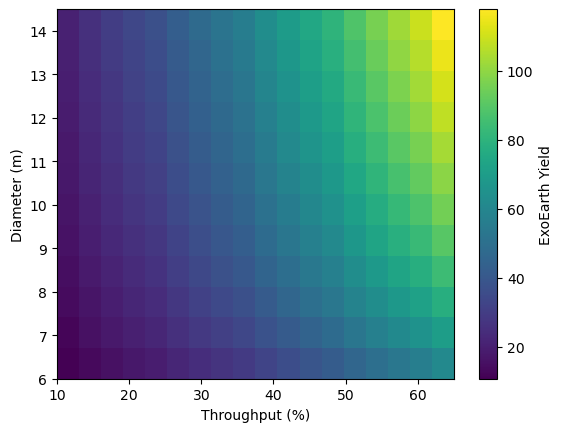

In [8]:
plt.imshow(k, extent = [min(tp)*100, max(tp)*100, min(dia), max(dia)], aspect = 'auto', origin = 'lower')
plt.xlabel('Throughput (%)')
plt.ylabel('Diameter (m)')
plt.colorbar(label='ExoEarth Yield')
#plt.imshow(k)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Yield variations with coronagraph parameters

In [9]:
outer_working_angle = np.arange(10, 25, 1) #outer working angle extent = 10 - 25 λ/D in 1 λ/D increments
inner_working_angle = np.arange(1, 5, 0.5) #inner working angle extent = 1 - 5 λ/D in 0.5 λ/D increments

k = np.zeros((len(outer_working_angle), len(inner_working_angle)))
for i in range(len(outer_working_angle)):
  for j in range(len(inner_working_angle)):
    k[i,j] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = inner_working_angle[j], OWA = outer_working_angle[i])


/var/folders/jw/l3psbkds2bg8nc7cp3qdkf500001gn/T/ipykernel_18274/1618854720.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k[i,j] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = inner_working_angle[j], OWA = outer_working_angle[i])


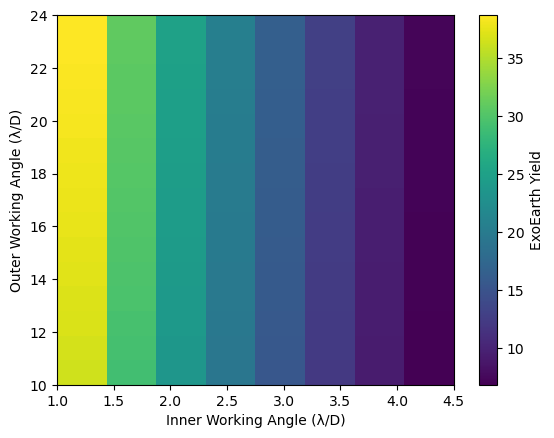

In [10]:
plt.imshow(k, extent = [min(inner_working_angle), max(inner_working_angle), min(outer_working_angle), max(outer_working_angle)], aspect = 'auto', origin = 'lower')
plt.xlabel('Inner Working Angle (λ/D)')
plt.ylabel('Outer Working Angle (λ/D)')
plt.colorbar(label='ExoEarth Yield')
#plt.imshow(k)

#Make 1D plots of impact of coronagraph parameters on Exo-Earth yield

/var/folders/jw/l3psbkds2bg8nc7cp3qdkf500001gn/T/ipykernel_18274/2623069244.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range(len(y)): y[i] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = 1, OWA = outer_working_angle[i])


Text(0.5, 1.0, 'Outer Working Angle')

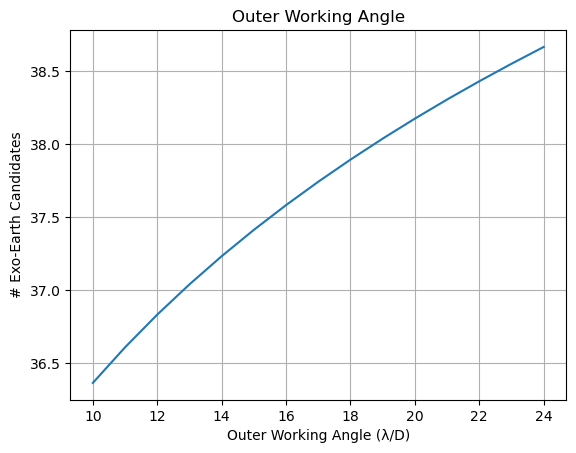

In [11]:
y = np.zeros(len(outer_working_angle))
for i in range(len(y)): y[i] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = 1, OWA = outer_working_angle[i])
plt.plot(outer_working_angle, y)
plt.xlabel('Outer Working Angle (λ/D)')
plt.ylabel('# Exo-Earth Candidates')
plt.grid()
plt.title('Outer Working Angle')

/var/folders/jw/l3psbkds2bg8nc7cp3qdkf500001gn/T/ipykernel_18274/3471061841.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range(len(y)): y[i] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = inner_working_angle[i])


Text(0.5, 1.0, 'Inner Working Angle ')

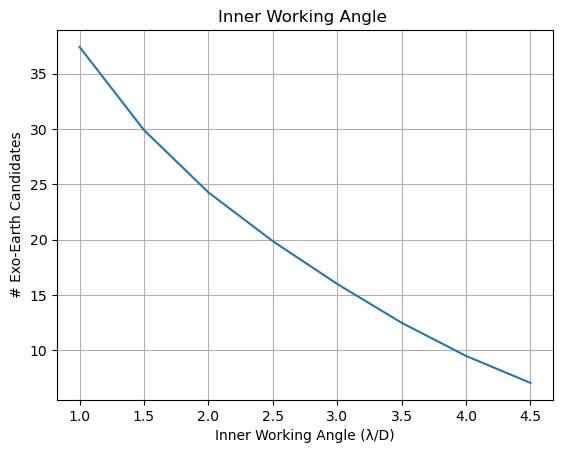

In [12]:
y = np.zeros(len(inner_working_angle))
for i in range(len(y)): y[i] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = inner_working_angle[i])
plt.plot(inner_working_angle, y)
plt.xlabel('Inner Working Angle (λ/D)')
plt.ylabel('# Exo-Earth Candidates')
plt.grid()
plt.title('Inner Working Angle ')